# 06 — Modelo: SVM

Implementação do modelo SVM com Scikit-Learn.

**Etapas obrigatórias (conforme projeto da disciplina):**
1. Construir SVM regularizando C e γ via cross validation
   - Tamanho do fold definido pela dimensão do conjunto de treino
2. Computar E_in, E_out e E_out esperado (baseado em vetores de suporte)
3. Computar métricas de qualidade do melhor modelo

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import build_svm, svm_expected_eout
from src.evaluation import (
    compute_metrics,
    compute_ein_eout,
    plot_confusion_matrix,
    print_classification_report,
)
from src.utils import save_model, FIGURES_DIR, DATA_PROCESSED

%matplotlib inline

In [2]:
X_train = np.load(DATA_PROCESSED / 'X_train.npy')
X_test  = np.load(DATA_PROCESSED / 'X_test.npy')
y_train = np.load(DATA_PROCESSED / 'y_train.npy')
y_test  = np.load(DATA_PROCESSED / 'y_test.npy')

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Dados normalizados (StandardScaler): média≈{X_train.mean():.2e}, std≈{X_train.std():.4f}")

Treino: (4456, 15) | Teste: (1114, 15)
Dados normalizados (StandardScaler): média≈2.04e-16, std≈1.0000


## 6.1 GridSearchCV para C e γ

O SVM com kernel RBF tem dois hiperparâmetros principais:

- **C** (regularização): penaliza violações da margem. C alto → margem estreita, menos erros no treino (risco de overfitting); C baixo → margem larga, mais erros tolerados (risco de underfitting).
- **γ (gamma)**: controla o raio de influência de cada amostra no kernel $K(x, x') = e^{-\gamma \|x - x'\|^2}$. γ alto → influência local (overfitting); γ baixo → influência global (underfitting).

**Grade de busca:** 5 × 5 = 25 combinações em escala logarítmica (C ∈ {0.01, 0.1, 1, 10, 100}; γ ∈ {0.001, 0.01, 0.1, 1, 'scale'}).

**Justificativa de cv=10 e scoring='f1':** Consistente com a árvore de decisão — 10 folds com N=4.456 produz estimativas de baixo viés; F1 é mais discriminativo que acurácia para seleção de hiperparâmetros em classificação binária.

In [3]:
best_svm, grid_search = build_svm(X_train, y_train, cv_folds=10, random_state=42)

bp = grid_search.best_params_
print(f"Melhores hiperparâmetros: C={bp['C']}, gamma={bp['gamma']}")
print(f"Melhor F1 (CV 10-fold):   {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")
print(f"\nTotal de combinações avaliadas: {len(grid_search.cv_results_['mean_test_score'])}")

Melhores hiperparâmetros: C=100, gamma=0.001
Melhor F1 (CV 10-fold):   0.7020 (70.20%)

Total de combinações avaliadas: 25


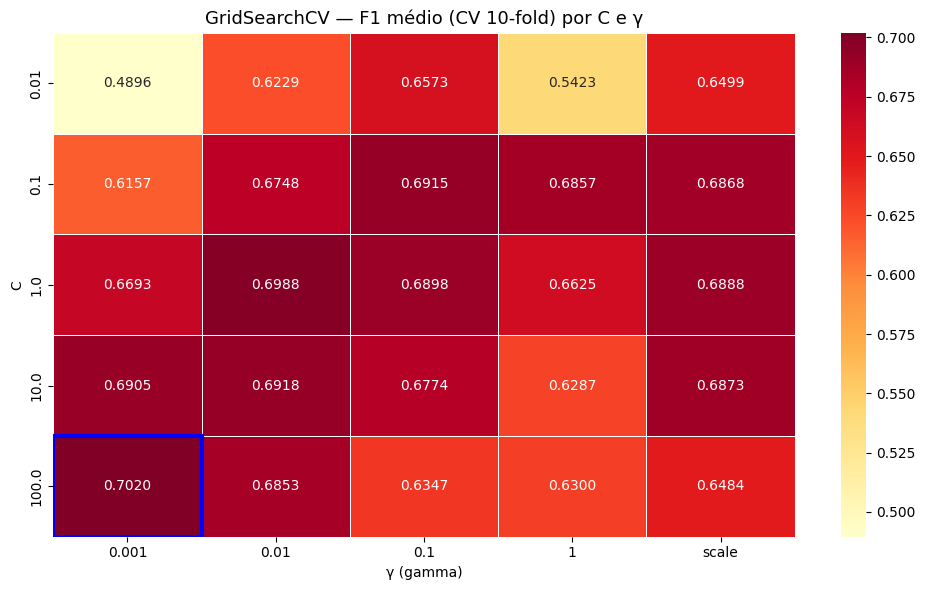

In [4]:
import pandas as pd

results = grid_search.cv_results_
C_vals     = [p['C']     for p in results['params']]
gamma_vals = [str(p['gamma']) for p in results['params']]
scores     = results['mean_test_score']

# Monta pivot para heatmap
C_unique     = sorted(set(C_vals))
gamma_unique = sorted(set(gamma_vals), key=lambda x: (x == 'scale', float(x) if x != 'scale' else 0))
pivot = pd.DataFrame(index=C_unique, columns=gamma_unique, dtype=float)
for c, g, s in zip(C_vals, gamma_vals, scores):
    pivot.loc[c, g] = s

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
ax.set_title('GridSearchCV — F1 médio (CV 10-fold) por C e γ', fontsize=13)
ax.set_xlabel('γ (gamma)')
ax.set_ylabel('C')

# Marca o melhor
best_c   = str(bp['C'])
best_g   = str(bp['gamma'])
col_idx  = list(pivot.columns).index(best_g)
row_idx  = list(pivot.index).index(bp['C'])
ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1, fill=False, edgecolor='blue', lw=3))

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_svm_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2 Análise de Overfitting e E_out esperado

Para o SVM, além do E_out empírico, existe um limitante teórico baseado nos **vetores de suporte**:

$$E_{out} \leq \mathbb{E}\left[\frac{\text{N° de vetores de suporte}}{N}\right]$$

Isso decorre do Teorema LOO do SVM: remover um vetor de suporte pode mudar a fronteira de decisão, portanto o erro leave-one-out é limitado superiormente pela fração de vetores de suporte no conjunto de treino.

In [5]:
errors = compute_ein_eout(best_svm, X_train, y_train, X_test, y_test)

n_sv       = int(best_svm.n_support_.sum())
n_sv_class = best_svm.n_support_
eout_exp   = svm_expected_eout(n_sv, len(X_train))

print(f"=== SVM — C={bp['C']}, γ={bp['gamma']} ===")
print(f"\nVetores de suporte:")
print(f"  Classe 0 (Baixa violência): {n_sv_class[0]}")
print(f"  Classe 1 (Alta  violência): {n_sv_class[1]}")
print(f"  Total:  {n_sv} / {len(X_train)} ({n_sv/len(X_train)*100:.1f}% do treino)")
print(f"\nErros:")
print(f"  E_in               = {errors['E_in']:.4f}  ({errors['E_in']*100:.2f}%)")
print(f"  E_out (empírico)   = {errors['E_out']:.4f} ({errors['E_out']*100:.2f}%)")
print(f"  E_out (esperado ≤) = {eout_exp:.4f} ({eout_exp*100:.2f}%)")
print(f"  Gap E_out-E_in     = {errors['gap']:.4f} → Overfitting: {'Sim' if errors['overfitting'] else 'Não'}")
print(f"\nInterpretação: E_out empírico ({errors['E_out']*100:.2f}%) < E_out esperado ({eout_exp*100:.2f}%) ✓"
      if errors['E_out'] <= eout_exp else
      f"\nAtenção: E_out empírico ({errors['E_out']*100:.2f}%) > limitante teórico ({eout_exp*100:.2f}%)")

=== SVM — C=100, γ=0.001 ===

Vetores de suporte:
  Classe 0 (Baixa violência): 1614
  Classe 1 (Alta  violência): 1619
  Total:  3233 / 4456 (72.6% do treino)

Erros:
  E_in               = 0.3131  (31.31%)
  E_out (empírico)   = 0.3339 (33.39%)
  E_out (esperado ≤) = 0.7255 (72.55%)
  Gap E_out-E_in     = 0.0209 → Overfitting: Não

Interpretação: E_out empírico (33.39%) < E_out esperado (72.55%) ✓


## 6.3 Métricas de Qualidade


Relatório de Classificação — SVM (RBF)
                 precision    recall  f1-score   support

Baixa Violência       0.68      0.62      0.65       557
 Alta Violência       0.65      0.71      0.68       557

       accuracy                           0.67      1114
      macro avg       0.67      0.67      0.67      1114
   weighted avg       0.67      0.67      0.67      1114



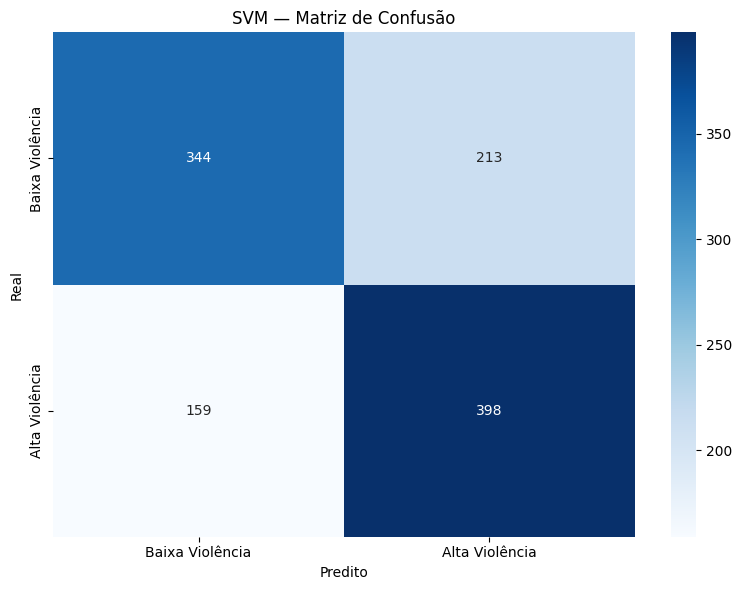


Métricas no conjunto de teste:
  accuracy: 0.6661
  precision: 0.6514
  recall: 0.7145
  f1_score: 0.6815


In [6]:
y_pred = best_svm.predict(X_test)
print_classification_report(y_test, y_pred, 'SVM (RBF)')
plot_confusion_matrix(y_test, y_pred, 'SVM — Matriz de Confusão',
                      save_path=str(FIGURES_DIR / '06_svm_confusion.png'))

metrics = compute_metrics(y_test, y_pred)
print("\nMétricas no conjunto de teste:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

In [7]:
save_model(best_svm, 'svm')
print("Modelo salvo em models/svm.joblib")

Modelo salvo em models/svm.joblib
